# Quick start

This page provides a minimal walkthrough for simulating the temperature of 
switchgear using this package. The goal is to demonstrate the core workflow with
sensible defaults, rather than cover the full API.

The quick start is structured as follows:

1. Preparing the required input data  
2. Running the temperature simulation  
3. Inspecting and interpreting the results  

We begin by importing the required modules.

### Imports

The example relies on a small set of standard scientific Python libraries for
data handling and visualisation, together with the core components of the
switchgear thermal model.

From the package itself, we import:
- `InputProfile`, which defines the structure of the time‑dependent input data,
- `Switchgear`, the main domain object describing the installation,
- `switchgear_temp`, the function that performs the temperature simulation.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from switchgear_thermal_model.schemas.input_profile import InputProfile
from switchgear_thermal_model.switchgear import Switchgear
from switchgear_thermal_model.thermal_model import switchgear_temp

## 1. Collecting the necessary input data

To run a temperature simulation, three categories of input are required:

- a load profile  
- an ambient temperature profile  
- a set of thermal parameters  

The load profile is provided as a time series of electrical current (in Ampère).  
It must be timestamped and is expected to have a regular sampling interval,
preferably 15 minutes or finer.

In [2]:
one_week = 4 * 24 * 7
datetime_index = pd.date_range("2025-01-01", periods=one_week, freq="15min")

# A sinusoidal load with a peak load of 1000 A is defined
n_cycles = 7  # 1 cycle per day
load_points = 500 + 500 * np.sin(np.linspace(0, n_cycles * 2 * np.pi, one_week))
load_points_series = pd.Series(np.ones(len(datetime_index)) * load_points, index=datetime_index)
display(load_points_series)

2025-01-01 00:00:00    500.000000
2025-01-01 00:15:00    532.750230
2025-01-01 00:30:00    565.359801
2025-01-01 00:45:00    597.688657
2025-01-01 01:00:00    629.597947
                          ...    
2025-01-07 22:45:00    370.402053
2025-01-07 23:00:00    402.311343
2025-01-07 23:15:00    434.640199
2025-01-07 23:30:00    467.249770
2025-01-07 23:45:00    500.000000
Freq: 15min, Length: 672, dtype: float64

In addition, an ambient temperature profile is required. This time series must
use the same timestamps as the load profile to ensure proper alignment during
the simulation.

For the purpose of this example, a constant ambient temperature of 20 °C is
assumed.


In [3]:
ambient_temp = 20
temperature_points = pd.Series([ambient_temp] * one_week, index=datetime_index)
display(temperature_points)

2025-01-01 00:00:00    20
2025-01-01 00:15:00    20
2025-01-01 00:30:00    20
2025-01-01 00:45:00    20
2025-01-01 01:00:00    20
                       ..
2025-01-07 22:45:00    20
2025-01-07 23:00:00    20
2025-01-07 23:15:00    20
2025-01-07 23:30:00    20
2025-01-07 23:45:00    20
Freq: 15min, Length: 672, dtype: int64

Finally, a set of thermal parameters is required to define the `Switchgear`
object. These parameters describe the thermal behaviour of the installation and
are treated as static inputs to the model.

For a detailed discussion of the individual parameters and guidance on how to
determine them in practice, refer to the
[switchgear thermal parameters](../theoretical_documentation/determining_switchgear_parameters.md)
documentation.

For this quick start example, we use the following parameter values:

In [4]:
nominal_load_capacity = 800  # [Ampère]
nominal_temperature_rise = 75  # [Kelvin]
thermal_time_constant = 60  # [minutes]
thermal_exponent = 1.8  # [-]

## 2. Performing the temperature simulation

With the input profiles and thermal parameters defined, we can now construct a `Switchgear` instance. This object encapsulates the physical and thermal characteristics of the installation and serves as the input to the temperature model.


In [5]:
profile_input = InputProfile.create(
    datetime_index=datetime_index, load_profile=load_points_series, ambient_temperature_profile=temperature_points
)
example_switchgear = Switchgear(
    rated_current=nominal_load_capacity,
    measured_temperature_rise=nominal_temperature_rise,
    temp_rise_exp=thermal_exponent,
    thermal_time_constant=thermal_time_constant,
)

The `InputProfile` and the `Switchgear` objects are then passed to the thermal
model to compute the temperature evolution over time.

In [6]:
result = switchgear_temp(profile_input, example_switchgear)

## 3. Assessing the results

With the simulation complete, we can now inspect and visualise the resulting
temperature profiles.

Text(0, 0.5, 'Conductor temperature [$^{\\circ}$C]')

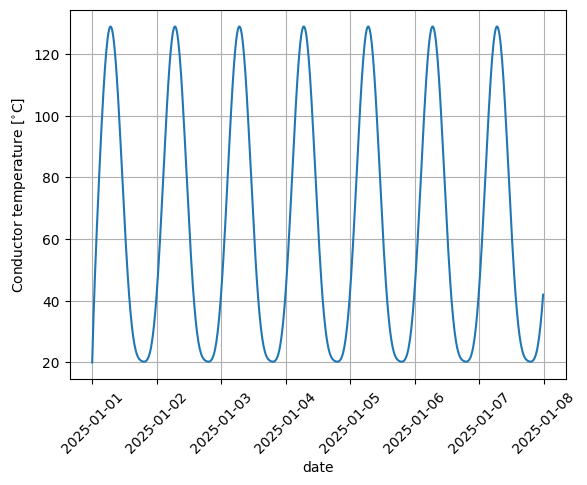

In [7]:
plt.figure()
plt.plot(datetime_index, result)
plt.grid("on")
plt.xticks(rotation=45)
plt.xlabel("date")
plt.ylabel("Conductor temperature [$^{\\circ}$C]")